The pr-work #6

First name - Rodion

Second name - Ostapenko

Group - CS-24

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

### I. Data Loading and Initial Inspection

In [67]:
df = pd.read_csv(r'\src\drug200.csv')
df.head(10)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
5,22,F,NORMAL,HIGH,8.607,drugX
6,49,F,NORMAL,HIGH,16.275,DrugY
7,41,M,LOW,HIGH,11.037,drugC
8,60,M,NORMAL,HIGH,15.171,DrugY
9,43,M,LOW,NORMAL,19.368,DrugY


In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 9.5 KB


In [69]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [84]:
print("Duplicates:", df.duplicated(keep=False).sum())
print("Nulls:", df.isnull().sum().sum())

Duplicates: 0
Nulls: 0


No duplicates or nulls were found

### II. Exploratory Data Analysis (EDA)

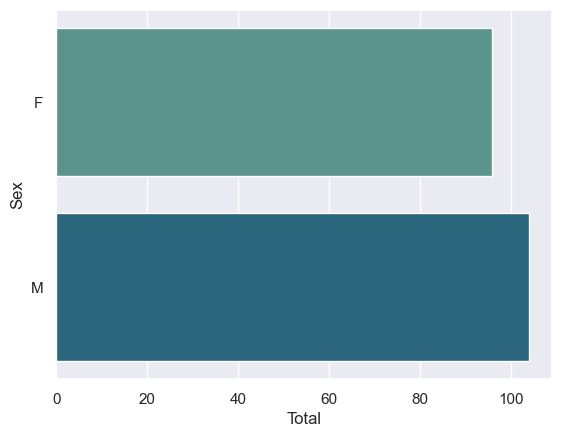

In [71]:
# Sex Distribution
sns.set_theme(style="darkgrid")
sns.countplot(y="Sex", data=df, hue="Sex", palette="crest", legend=False)
plt.ylabel('Sex')
plt.xlabel('Total')
plt.show()

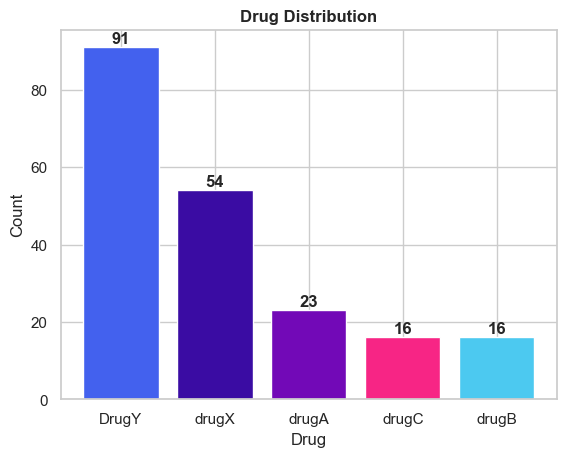

In [90]:
# Drug_Type Distribution
sns.set_theme(style='whitegrid')
counts = df['Drug'].value_counts()
plt.bar(counts.index, counts.values, color=['#4361EE','#3A0CA3','#7209B7','#F72585','#4CC9F0'])
plt.title('Drug Distribution', fontweight='bold')
plt.xlabel('Drug')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v+1, str(v), ha='center', fontweight='bold')

#### The plots show us that the data is balanced across both genders. However, the distribution of drugs indicates that DrugY was used far more frequently than the others, this should be kept in mind when training the model

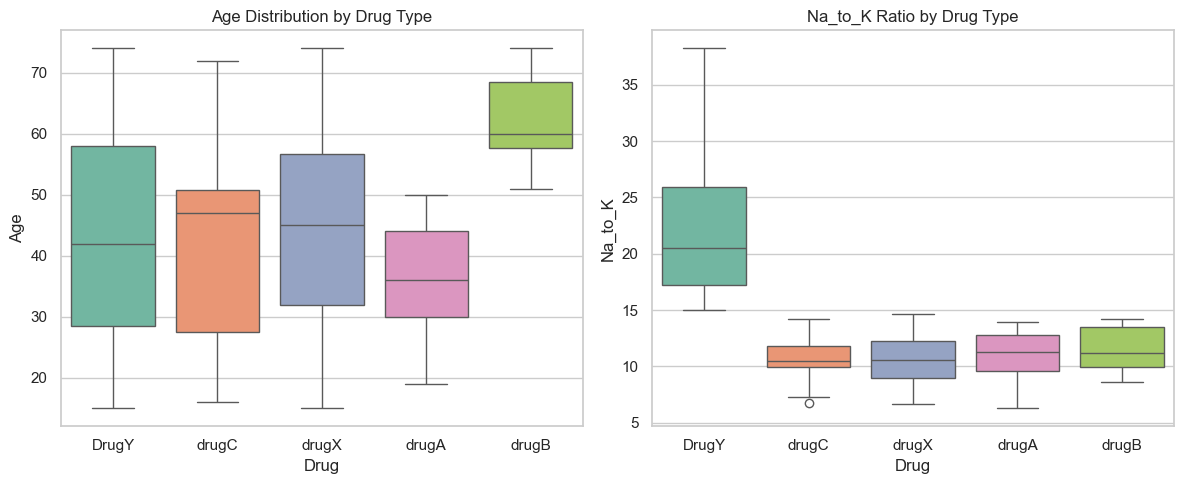

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


sns.boxplot(data=df, x="Drug", y="Age", hue="Drug", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Age Distribution by Drug Type")

sns.boxplot(data=df, x="Drug", y="Na_to_K", hue="Drug", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Na_to_K Ratio by Drug Type")

plt.tight_layout()
plt.show()

#### It is clear that the high age category is associated only with DrugB, whereas DrugY is suitable for all age groups.
#### The second plot clearly shows that a low Na_to_K ratio is not suitable for DrugY - it carries the greatest weight in determining the drug.

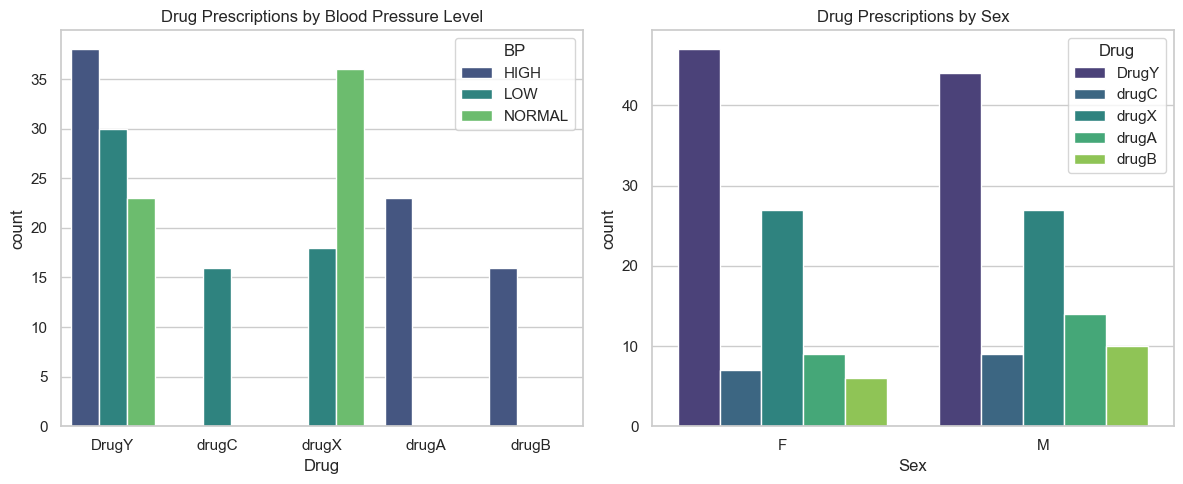

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="Drug", hue="BP", palette="viridis", ax=axes[0])
axes[0].set_title("Drug Prescriptions by Blood Pressure Level")

sns.countplot(data=df, x="Sex", hue="Drug", palette="viridis", ax=axes[1])
axes[1].set_title("Drug Prescriptions by Sex")

plt.tight_layout()
plt.show()

#### We can clearly see how specific drugs are used depending on blood pressure levels, but DrugY is often used regardless of that feature.
#### There are almost no differences in the use of drugs between the sexes.

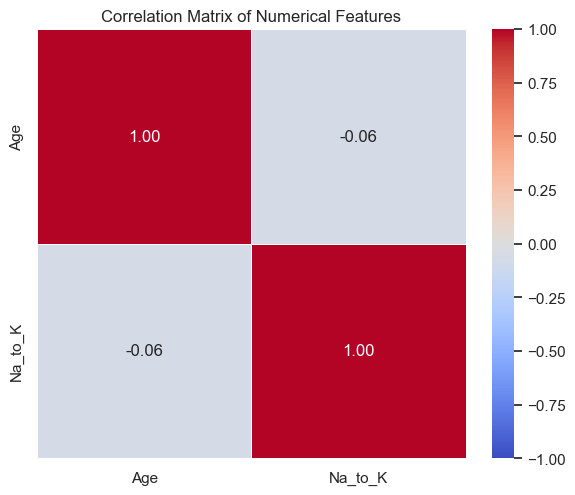

In [75]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(6, 5))

sns.heatmap(corr_matrix, 
            annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1,
            center=0,
            linewidths=0.5,
            fmt=".2f",
            square=True)

plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

#### At that moment the correlation matrix shows only that there is no correlation between age and the Na_to_K features. 
#### It would be better to return to this once the other columns have been encoded.

### III. Feature Engineering and Encoding

In [76]:
bp_mapping = {'LOW': 0, 'NORMAL': 1, 'HIGH': 2}
chol_mapping = {'NORMAL': 0, 'HIGH': 1}

df['BP_encoded'] = df['BP'].map(bp_mapping)
df['Cholesterol_encoded'] = df['Cholesterol'].map(chol_mapping)

df = pd.get_dummies(df, columns=['Sex'], drop_first=True, dtype=int) 

le = LabelEncoder()
df['Drug_encoded'] = le.fit_transform(df['Drug'])

columns_to_drop = ['BP', 'Cholesterol', 'Drug']
df_clean = df.drop(columns=columns_to_drop)
df_clean.head(10)

,Age,Na_to_K,BP_encoded,Cholesterol_encoded,Sex_M,Drug_encoded
0,23,25.355,2,1,0,0
1,47,13.093,0,1,1,3
2,47,10.114,0,1,1,3
3,28,7.798,1,1,0,4
4,61,18.043,0,1,0,0
5,22,8.607,1,1,0,4
6,49,16.275,1,1,0,0
7,41,11.037,0,1,1,3
8,60,15.171,1,1,1,0
9,43,19.368,0,0,1,0


### IV. Final Data Preparation and Scaling

In [80]:
cols_to_scale = ['Age', 'Na_to_K']

scaler = StandardScaler()

df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])
df_clean.head(10)

,Age,Na_to_K,BP_encoded,Cholesterol_encoded,Sex_M,Drug_encoded
0,-1.291591,1.286522,2,1,0,0
1,0.162699,-0.415145,0,1,1,3
2,0.162699,-0.828558,0,1,1,3
3,-0.988614,-1.149963,1,1,0,4
4,1.011034,0.271794,0,1,0,0
5,-1.352186,-1.037693,1,1,0,4
6,0.283889,0.026439,1,1,0,0
7,-0.200874,-0.700468,0,1,1,3
8,0.950439,-0.126770,1,1,1,0
9,-0.079683,0.455672,0,0,1,0


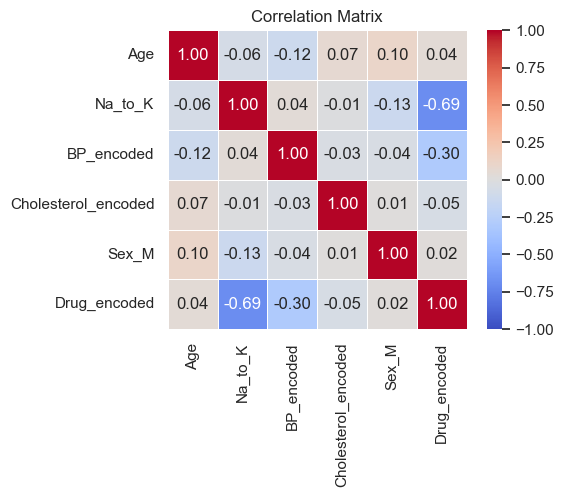

In [88]:
corr_matrix = df_clean.corr(numeric_only=True)

plt.figure(figsize=(6, 5))

sns.heatmap(corr_matrix, 
            annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1,
            center=0,
            linewidths=0.5,
            fmt=".2f",
            square=True)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

#### After the data has been encoded strong correlations are clearly shows between the target variable and Na_to_K and BP_encoded. 
#### Those are the most important determining factors when prescribing drugs.

In [85]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  200 non-null    float64
 1   Na_to_K              200 non-null    float64
 2   BP_encoded           200 non-null    int64  
 3   Cholesterol_encoded  200 non-null    int64  
 4   Sex_M                200 non-null    int64  
 5   Drug_encoded         200 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 9.5 KB


In [87]:
print("Nulls:", df_clean.isnull().sum().sum())

Nulls: 0


In [89]:
filename = 'ML_ready_drug_dataset.csv'
df_clean.to_csv(filename, index=False)